# Pathway analysis

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import sys
sys.path.append('../../scripts')

import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import decoupler as dc
import hotspot

from cellina import CellinaModel
from utils import set_seed
from train_loo import _preprocess_adata
from plotting import plot_pathway_activity, plot_custom_umap
from helpers import (
    _normalize_counts, safe_log2_fold_change, compute_correlations, subsample_adata,
    compute_microenv_logfc, _pw_concordant_series, _all_de_series,
    build_perturbation_dict, cf_logfc,
)


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

In [2]:
set_seed(0)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.dpi'] = 100

slide_id = 'crc_210'
labels_key  = 'coarse_type'
domains_key = 'typ_clean'
batch_key   = 'sid'
fig_save_path = '../../figures/application'

# ── Load Part 1 outputs ────────────────────────────────────────────────────
adata = sc.read_h5ad("output/adata_with_microenv.h5ad")
print(f"Loaded adata: {adata}")

with open("output/hotspot.pkl", "rb") as _f:
    hs = pickle.load(_f)
print("Loaded hotspot object")

with open("output/results.pkl", "rb") as _f:
    results = pickle.load(_f)
print(f"Loaded results dict with keys: {list(results.keys())}")

model_base_path = f"./{slide_id}"
checkpoint_name = os.listdir(model_base_path)[0]
model = CellinaModel.load(
    f"{model_base_path}/{checkpoint_name}",
    adata=adata,
)
print("Loaded model")

adata.obsm['recon_x'] = model.get_normalized_expression(adata=adata, batch_size=4096, library_size=1e4)
print("Computed recon_x")
microenvironments = [m for m in adata.obs['microenvironment'].unique() if 'CRC' in str(m)]
print(f"Microenvironments: {microenvironments}")

Loaded adata: AnnData object with n_obs × n_vars = 552241 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'fals

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-04-27 16:22:30 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Loaded results dict with keys: ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'T_cell']
INFO     File ./crc_210/epoch=26-step=5720-vae_loss_validation=309.9802551269531/model.pt already downloaded       


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.l

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
Loaded model
Computed recon_x
Microenvironments: ['CRC2', 'CRC3', 'CRC1']


## Counterfactual fibroblast UMAP

In [3]:
# subsample_adata imported from helpers (cell 1)


In [4]:
# Get cellina spatial for non CRC cells
adata_list = []
select_ct = "Fibroblast"
adata_fib = results[select_ct].copy()
control_mask = adata_fib.obs[domains_key].astype(str).str.contains('REF')
X = adata_fib.obsm['recon_x'][control_mask.values, :]
X = np.log1p(X)
adata_control = ad.AnnData(X=X, 
                           obs=adata_fib.obs[control_mask])
#adata_list.append(subsample_adata(adata_control, fraction=0.1, random_state=0))
adata_list.append(subsample_adata(adata_control, fraction=1, random_state=0))

for microenv in microenvironments:
    # Get real latents for cells in this microenvironment
    real_mask = adata.obs['microenvironment'].astype(str).str.contains(microenv) & (adata.obs[labels_key].astype(str) == select_ct)
    X = adata.obsm['recon_x'][real_mask.values, :]
    X = np.log1p(X)
    obs=adata.obs[real_mask]
    adata_real = ad.AnnData(X=X, obs=obs)
    adata_real.obs['microenvironment'] = microenv
    #adata_list.append(subsample_adata(adata_real, fraction=0.2, random_state=0))
    adata_list.append(subsample_adata(adata_real, fraction=1., random_state=0))
    
    # Get counterfactual latents for this microenvironment
    X = adata_fib.uns[f'counterfactual_x_{microenv}']
    X = np.log1p(X)
    obs = adata_fib.obs[~adata_fib.obs[domains_key].str.contains('CRC')]
    obs['microenvironment'] = f"{microenv}_counterfactual"
    adata_cf = ad.AnnData(X=X, obs=obs)
    #adata_list.append(subsample_adata(adata_cf, fraction=0.1, random_state=0))
    adata_list.append(subsample_adata(adata_cf, fraction=1., random_state=0))

/tmp/ipykernel_3495029/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['microenvironment'] = f"{microenv}_counterfactual"
/tmp/ipykernel_3495029/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['microenvironment'] = f"{microenv}_counterfactual"
/tmp/ipykernel_3495029/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

In [5]:
# Merge all adatas in list
adata_fib_merged = ad.concat(adata_list, join='outer')
adata_fib_merged.obs_names_make_unique()

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
sc.pp.pca(adata_fib_merged, n_comps=50)
sc.pp.neighbors(adata_fib_merged, n_pcs=20)
sc.tl.umap(adata_fib_merged)

In [7]:
# rename REF, TVA to control
#adata_fib_merged.obs['microenvironment'] = adata_fib_merged.obs['microenvironment'].replace({'REF': 'Control', 'TVA': 'Control'})
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['microenvironment']
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['domain'].replace({'210_REF': 'Control'})
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['domain'].astype('category')

In [8]:
palette = {
    'CRC1': "#580803",
    'CRC1 CF': '#F4A582',  # lighter version
    'CRC2': "#011080",
    'CRC2 CF': '#92C5DE',  # lighter version
}

In [9]:
adata_fib_merged.obs['domain'].value_counts()

domain
CRC1                   29626
CRC3                    7242
CRC1_counterfactual     7006
CRC3_counterfactual     7006
CRC2_counterfactual     7006
CRC2                    4661
Control                 2456
Name: count, dtype: int64

/tmp/ipykernel_3495029/1030890215.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_sub.obs['domain_short'] = adata_sub.obs['domain'].replace({
... storing 'cell_id' as categorical
... storing 'cell' as categorical
... storing 'microenvironment' as categorical


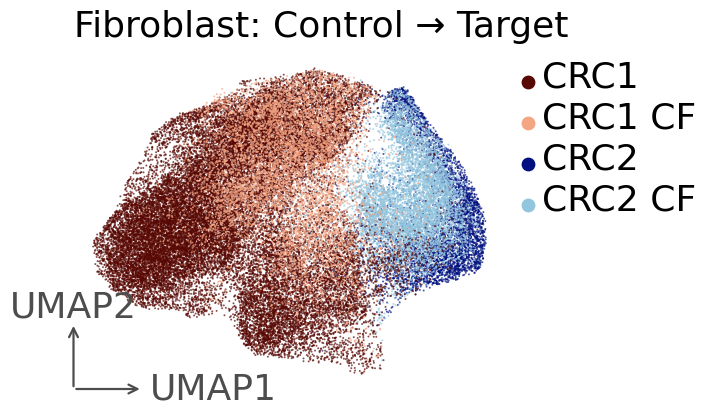

../../figures/application/crc_210_umap_cf_Fibroblasts.svg


In [10]:
import matplotlib.pyplot as plt
import scanpy as sc

domains = ['CRC1', 'CRC1_counterfactual', 'CRC2', 'CRC2_counterfactual'] # 'Control',
adata_sub = adata_fib_merged[adata_fib_merged.obs['domain'].isin(domains)].copy()

adata_sub.obs['domain_short'] = adata_sub.obs['domain'].replace({
    'Control': 'Control',
    'CRC1': 'CRC1',
    'CRC1_counterfactual': 'CRC1 CF',
    'CRC2': 'CRC2',
    'CRC2_counterfactual': 'CRC2 CF'
})

ax = sc.pl.umap(
    adata_sub,
    color='domain_short',
    palette=palette,
    show=False,
    title='',
    size=8,
    alpha=0.7,
    frameon=False,
)

fig = ax.figure
fig.set_size_inches(6, 4)
ax.set_position([0.05, 0.08, 0.72, 0.84])

ax.set_title(
    f"{select_ct}: Control → Target",
    fontsize=26,
    # fontweight='bold',
    pad=12,
    loc='left',
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

arrow_kw = dict(arrowstyle='->', color='0.3', lw=1.6)
x0, y0 = ax.get_xlim()[0], ax.get_ylim()[0]
offset = (ax.get_xlim()[1] - x0) * 0.08
ax.annotate('', xy=(x0 + offset * 2, y0), xytext=(x0, y0),
            arrowprops=arrow_kw, annotation_clip=False)
ax.annotate('', xy=(x0, y0 + offset * 2), xytext=(x0, y0),
            arrowprops=arrow_kw, annotation_clip=False)
ax.text(x0 + offset * 2.2, y0, 'UMAP1', fontsize=26, color='0.3', va='center')
ax.text(x0, y0 + offset * 2.2, 'UMAP2', fontsize=26, color='0.3', ha='center')

legend = ax.get_legend()
if legend is not None:
    legend.set_title('')
    legend.get_frame().set_linewidth(0)
    legend.get_frame().set_alpha(0)
    for text in legend.get_texts():
        text.set_fontsize(26)
    for handle in legend.legend_handles:
        handle.set_sizes([80])
    legend.set_bbox_to_anchor((1.02, 1))
    legend.set_loc('upper left')

for coll in ax.collections:
    coll.set_rasterized(True)

plt.show()

fig.savefig(
    f"{fig_save_path}/{slide_id}_umap_cf_Fibroblasts.svg",
    dpi=300,
    bbox_inches='tight',
    transparent=True,
)
print(f"{fig_save_path}/{slide_id}_umap_cf_Fibroblasts.svg")

In [11]:
f"{select_ct}: Control → Target"

'Fibroblast: Control → Target'

### Pathways

In [12]:
# plot_pathway_activity imported from plotting in cell 1


In [13]:
# Get module x gene matrix
gene_modules = hs.modules
gene_c = hs.results[['C']]
df = gene_c.join(gene_modules.rename("Module"))
df = df[~(df["Module"].isna()) & (df["Module"] != -1.0)] # NOTE: drop NaNs and -1 (unassigned genes)
module_gene_matrix = df.pivot_table(index="Module", columns=df.index, values="C", fill_value=0)

In [14]:
hs.results[['C']]

,C
Gene,
CXCL8,0.203648
COL1A1,0.212519
IGHG1,0.128171
HCAR3,0.099143
SOCS3,0.101994
...,...
IL12RB2,-0.000243
ZNF680,-0.000291
KIAA0040,-0.000469


In [15]:
df['Module'].unique()

array([2., 1., 3.])

In [16]:
module_gene_matrix

Gene,A2M,ABCA1,ABCB1,ABHD2,ABI3,ACAN,ACKR1,ACKR3,ACP5,ACTA2,...,XDH,ZAP70,ZBTB16,ZC3H12A,ZCCHC24,ZEB2,ZFAND2A,ZFP36,ZNF773,ZNG1B
Module,,,,,,,,,,,,,,,,,,,,,
1.0,0.037729,0.004489,0.000000,0.000000,0.001868,0.001903,0.004795,0.001899,0.009763,0.028494,...,0.000000,0.001698,0.00771,0.000000,0.006575,0.010144,0.000000,0.00000,0.002754,0.006815
2.0,0.000000,0.000000,0.000000,0.015129,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.016833,0.000000,0.00000,0.021202,0.000000,0.000000,0.007954,0.06351,0.000000,0.000000
3.0,0.000000,0.000000,0.016138,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


In [17]:
pw_progeny = dc.op.progeny(organism="human")
pw_hallmark = dc.op.hallmark(organism="human")

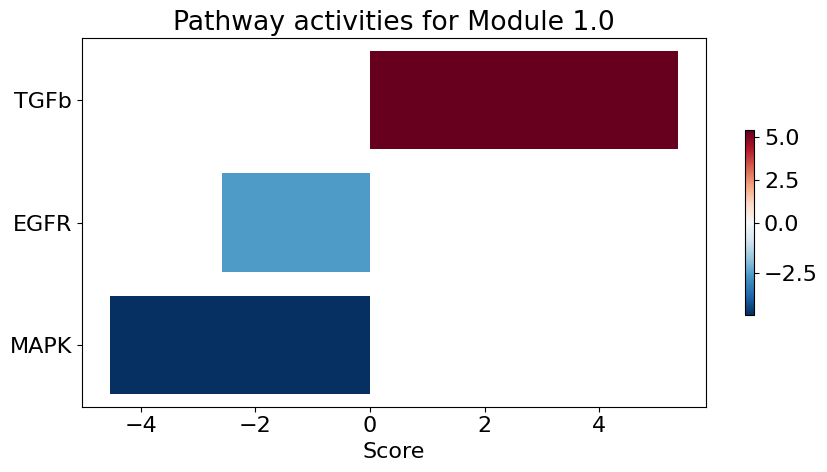

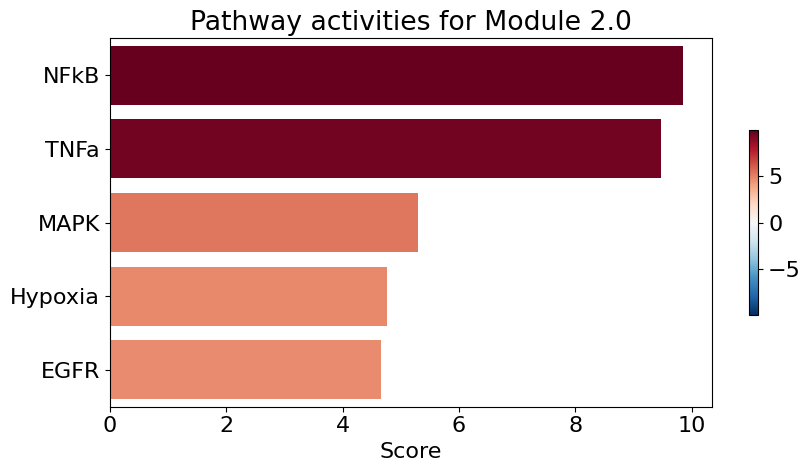

In [18]:
# Progeny pathway activity
pw_acts_progeny, pw_padj_progeny = dc.mt.ulm(data=module_gene_matrix, net=pw_progeny)
plot_pathway_activity(pw_acts_progeny, pw_padj_progeny, alpha=0.05)

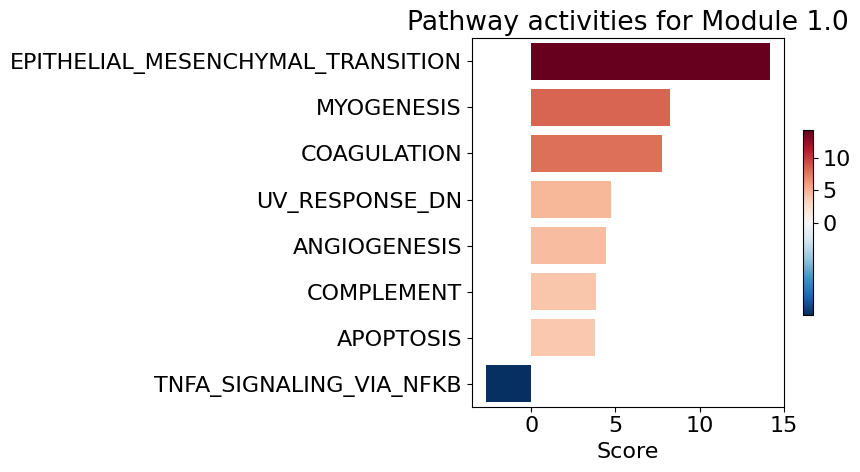

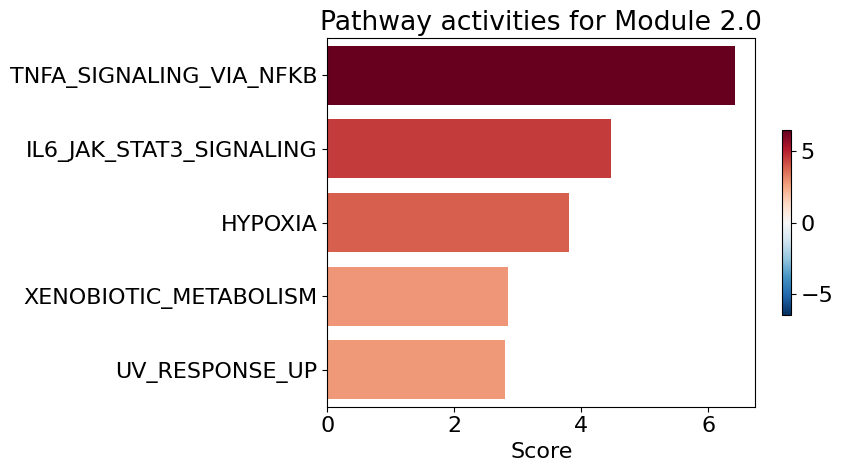

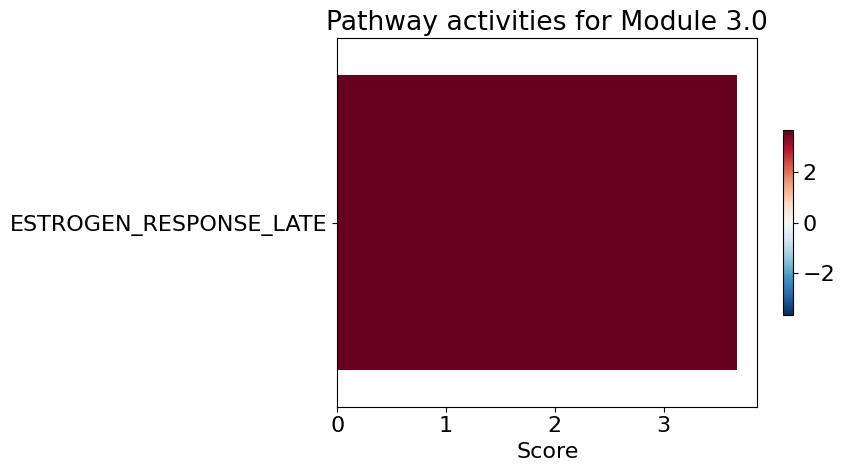

In [19]:
# Hallmark pathway activity
pw_acts_hallmark, pw_padj_hallmark = dc.mt.ulm(data=module_gene_matrix, net=pw_hallmark)
plot_pathway_activity(pw_acts_hallmark, pw_padj_hallmark, alpha=0.05)

In [20]:
pw_acts_joint = pw_acts_progeny.merge(pw_acts_hallmark, left_index=True, right_index=True).T
pw_padj_joint = pw_padj_progeny.merge(pw_padj_hallmark, left_index=True, right_index=True).T


In [21]:
# to long
pw_acts_long = pw_acts_joint.reset_index().melt(id_vars='index', var_name='Module', value_name='Activity').sort_values(['index', 'Module'])
pw_padj_long = pw_padj_joint.reset_index().melt(id_vars='index', var_name='Module', value_name='padj').sort_values(['index', 'Module'])
pw_joint = pw_acts_long.merge(pw_padj_long, on=['index', 'Module'])

In [22]:
# rename index to Pathway
pw_joint = pw_joint.rename(columns={'index': 'Pathway'})


In [23]:
pw_joint['Module'] = [f"CRC{int(float(col.split()[-1]))}" for col in pw_joint['Module']]

In [24]:
# rename index value 'EPITHELIAL_MESENCHYMAL_TRANSITION' to EMT
pw_joint['Pathway'] = pw_joint['Pathway'].str.replace('EPITHELIAL_MESENCHYMAL_TRANSITION', 'EMT')

In [25]:
pw_joint

,Pathway,Module,Activity,padj
0,ADIPOGENESIS,CRC1,1.182869,0.606805
1,ADIPOGENESIS,CRC2,-0.131238,0.959581
2,ADIPOGENESIS,CRC3,-0.785138,0.954660
3,ALLOGRAFT_REJECTION,CRC1,-0.029527,0.976449
4,ALLOGRAFT_REJECTION,CRC2,-0.380810,0.838830
...,...,...,...,...
172,XENOBIOTIC_METABOLISM,CRC2,2.842487,0.047481
173,XENOBIOTIC_METABOLISM,CRC3,0.373807,0.954660
174,p53,CRC1,0.878339,0.655096
175,p53,CRC2,1.988090,0.109738


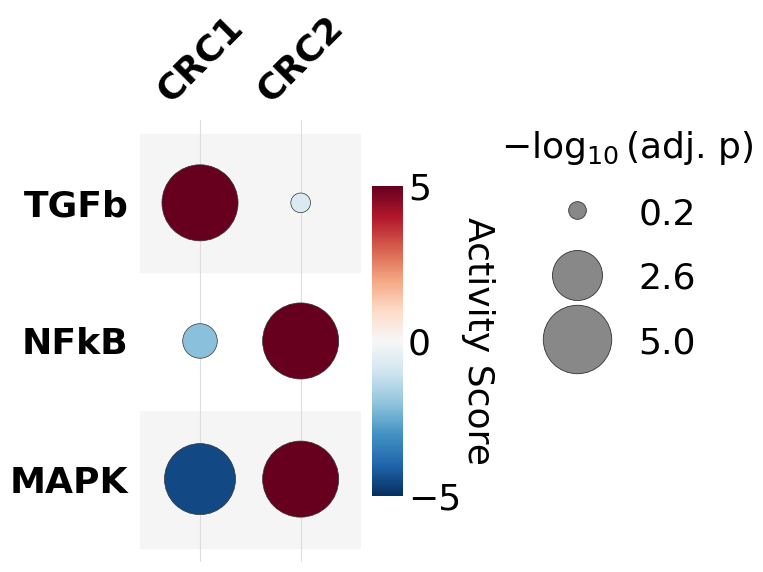

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns

# ── Selection ──────────────────────────────────────────────
MODULES  = ['CRC1', 'CRC2']
PATHWAYS = ['TGFb', 'NFkB', 'MAPK']
CLIP     = 5
# ──────────────────────────────────────────────────────────

plt.rcParams.update({
    'font.family':    'sans-serif',
    'font.monospace': ['Courier New', 'DejaVu Sans Mono'],
    'font.size':       16,
})

df = pw_joint[
    pw_joint['Pathway'].isin(PATHWAYS) &
    pw_joint['Module'].isin(MODULES)
].copy()

df['Activity_clipped'] = df['Activity'].clip(-CLIP, CLIP)
df['neg_log10_padj']   = -np.log10(df['padj'].clip(lower=1e-5))

pathway_order = PATHWAYS[::-1]
module_order  = MODULES
df['x'] = df['Module'].map({m: i for i, m in enumerate(module_order)})
df['y'] = df['Pathway'].map({p: i for i, p in enumerate(pathway_order)})

# ── Size scaling ───────────────────────────────────────────
MAX_SIZE, MIN_SIZE = 3000, 200
sig_min, sig_max = df['neg_log10_padj'].min(), df['neg_log10_padj'].max()
size_range = sig_max - sig_min or 1
dot_sizes = MIN_SIZE + (df['neg_log10_padj'] - sig_min) / size_range * (MAX_SIZE - MIN_SIZE)

# ── Figure ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for i in range(len(pathway_order)):
    ax.axhspan(i - 0.5, i + 0.5,
               color='#f5f5f5' if i % 2 == 0 else 'white', zorder=0)
for xi in range(len(module_order)):
    ax.axvline(xi, color='#dddddd', linewidth=0.8, zorder=1)

norm = mcolors.TwoSlopeNorm(vmin=-CLIP, vcenter=0, vmax=CLIP)
xx = ax.scatter(
    df['x'], df['y'],
    c=df['Activity_clipped'], s=dot_sizes,
    cmap='RdBu_r', norm=norm,
    edgecolors='#333333', linewidths=0.5,
    zorder=3,
)

ax.set_xticks(range(len(module_order)))
ax.set_yticks(range(len(pathway_order)))
ax.set_xticklabels(module_order, size=26, fontweight='bold', rotation=45, ha='center', va='bottom')
ax.set_yticklabels(pathway_order, size=26, fontweight='bold', rotation=0)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlim(-0.6, len(module_order) - 0.4)
ax.set_ylim(-0.6, len(pathway_order) - 0.4)
ax.tick_params(length=0, pad=8)
sns.despine(ax=ax, left=True, bottom=True, top=True, right=True)

# ── Colorbar — bigger, more readable ──────────────────────
cbar = fig.colorbar(
    xx, ax=ax,
    shrink=0.7,       # taller bar (was 0.4)
    pad=0.04,
    aspect=10,         # chunkier/wider bar (was 10)
    ticks=[-CLIP, 0, CLIP]
)
cbar.set_label('Activity Score', labelpad=0, rotation=270,
               va='bottom', fontsize=26)
cbar.ax.tick_params(labelsize=26, length=0)
cbar.outline.set_visible(False)

# ── Size legend — spread out, no overlap ──────────────────
# Use only 3 ticks and space them at 0%, 50%, 100% of the range
sig_ticks  = np.array([sig_min,
                        sig_min + 0.5 * size_range,
                        sig_max])
size_ticks = MIN_SIZE + (sig_ticks - sig_min) / size_range * (MAX_SIZE - MIN_SIZE)

legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#888888', markeredgecolor='#333333',
           markeredgewidth=0.6,
           markersize=np.sqrt(s) * 0.9,  # slightly bigger markers
           label=f'{v:.1f}')
    for s, v in zip(size_ticks, sig_ticks)
]
ax.legend(
    handles=legend_handles,
    title='$-\\log_{10}$(adj. p)',
    title_fontsize=26,        # was 14
    fontsize=26,              # was 14
    bbox_to_anchor=(1.55, 1.02),
    loc='upper left',
    frameon=False,
    labelspacing=0.8,         # was 1.2 — more vertical breathing room
    handletextpad=1.2,
)

plt.tight_layout()
plt.savefig("heatmap_dotplot.svg", bbox_inches="tight", dpi=300)
plt.savefig("heatmap_dotplot.pdf", bbox_inches="tight", dpi=300)
plt.show()

# Pathway-based perturbations

In [27]:
is_celltype1 = "Fibroblast"   # CRC1 perturbation
is_celltype2 = "Fibroblast"      # CRC2 perturbation


In [28]:
adata_pert     = results[is_celltype1].copy()
adata_ct2_pert = results[is_celltype2].copy()

In [29]:
for _ap in [adata_pert, adata_ct2_pert]:
    _ap.obs['domain'] = _ap.obs['microenvironment']
    _ap.obs['domain'] = _ap.obs['domain'].replace({'210_REF': 'Control'})
    _ap.obs['domain'] = _ap.obs['domain'].astype('category')

/tmp/ipykernel_3495029/1005614181.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  _ap.obs['domain'] = _ap.obs['domain'].replace({'210_REF': 'Control'})
/tmp/ipykernel_3495029/1005614181.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  _ap.obs['domain'] = _ap.obs['domain'].replace({'210_REF': 'Control'})


In [30]:
print(f"{is_celltype1} domains:"); display(adata_pert.obs.domain.value_counts())
print(f"{is_celltype2} domains:"); display(adata_ct2_pert.obs.domain.value_counts())

Fibroblast domains:


domain
CRC1       29626
CRC3        7242
CRC2        4661
210_TVA     4550
Control     2456
Name: count, dtype: int64

Fibroblast domains:


domain
CRC1       29626
CRC3        7242
CRC2        4661
210_TVA     4550
Control     2456
Name: count, dtype: int64

In [31]:
for _ap in [adata_pert, adata_ct2_pert]:
    _ap.X = _ap.layers['counts'].copy()
    sc.pp.normalize_total(_ap, target_sum=1e4)
    sc.pp.log1p(_ap)

1. Microenvironment subset


In [32]:
adata.obs['microenvironment'].replace({'210_REF': 'Control'}, inplace=True)

adata_sub = adata[adata.obs['microenvironment'].isin(['Control', 'CRC1', 'CRC2'])].copy()

_, ct_logfc_df_crc1 = compute_microenv_logfc(
    adata_sub, domains_key='microenvironment', labels_key=labels_key,
    ref_label='Control', crc_label='CRC1'
)
_, ct_logfc_df_crc2 = compute_microenv_logfc(
    adata_sub, domains_key='microenvironment', labels_key=labels_key,
    ref_label='Control', crc_label='CRC2'
)


/tmp/ipykernel_3495029/3289156282.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs['microenvironment'].replace({'210_REF': 'Control'}, inplace=True)
/tmp/ipykernel_3495029/3289156282.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['microenvironment'].replace({'210_REF': 'Control'}, inplace

In [33]:
ct_logfc_df_crc1

,CADPS,MMP9,AIF1,SLC5A9,TMEM212,AKR1B1,MXRA7,MS4A12,TRDMT1,B3GNT7,...,MEF2C,HPX,FOS,KCMF1,RSAD2,SLC24A3,KRT8,ADAM28,RAD54B,H1-5
B_cell,-0.118382,0.571938,-0.354907,0.000051,-0.067710,-0.030792,0.128278,-0.019881,-0.139243,-0.447966,...,0.425097,0.075836,-0.506038,-0.100413,-0.395406,-0.265602,-0.232924,-0.443892,-0.203850,0.481840
Endothelial,-0.598526,0.220158,-0.529538,-1.442191,-0.278372,0.372482,-0.113405,0.249860,-0.741500,-0.592452,...,-0.213352,-0.415244,0.201342,-0.121042,-0.622110,-0.151590,-0.155080,-0.786895,-0.153627,0.616945
Epithelial,0.215087,-0.140275,-0.475195,-0.243813,-0.273029,0.024181,0.165230,-2.933516,-0.291147,-1.828919,...,-0.430382,-0.404310,-0.931309,-0.097517,-0.311364,-0.449948,0.198876,-0.138351,-0.185232,0.656437
Fibroblast,-0.357249,0.206078,-0.820813,-0.446856,-0.391287,-0.366046,0.285840,-0.573573,-0.796548,-0.311996,...,-0.307708,-0.557581,-1.535843,-0.166957,0.035293,-0.054897,-0.473835,-2.301342,-0.290060,0.344855
Mast_cell,-0.595832,0.585351,-1.038135,-0.066470,-0.607839,1.310841,-0.161394,-1.267113,-0.081262,0.770629,...,-0.405004,-0.977546,-0.281140,-0.190334,1.136501,0.313186,-0.777086,-0.545975,-0.908498,0.001234
Myeloid,0.081087,1.329523,-0.426109,-0.379307,-0.595997,-0.025427,0.415320,-0.467444,0.008355,-0.382802,...,-0.164574,-0.694817,-0.693414,-0.242644,-0.287084,-0.359542,-0.362063,-0.893069,-0.162263,0.656527
Plasma_cell,-0.173697,0.137572,-0.201855,-0.048880,-0.065122,0.013727,0.219482,-0.203867,-0.022736,-0.211442,...,-0.128561,-0.098695,-0.564393,-0.000729,-0.071118,0.031281,-0.509216,-0.512396,-0.159796,0.182908
Smooth_muscle,-0.505282,0.088725,-0.473091,0.213840,-0.119186,0.326118,-0.256086,-0.308003,-0.422417,-0.307660,...,0.351773,-0.433598,-0.494169,-0.207753,-0.134301,-0.144317,-0.506775,-1.174964,0.009981,0.355884
T_cell,-0.408859,-0.050926,-0.084923,-0.202301,0.118282,0.171324,0.161072,-0.438991,-0.030524,-0.411706,...,-0.234033,-0.567801,-0.254187,0.713279,-0.246722,-0.141949,-0.495580,-0.634134,-0.327173,0.271066


2. Find pathway-defining genes

In [34]:
logfc_threshold  = 0.5
padj_threshold   = 0.1
weight_threshold = 0.5


In [35]:
pw_tgfb = pw_progeny[(pw_progeny.source == 'TGFb') & (pw_progeny.weight.abs() > weight_threshold)]
pw_mapk = pw_progeny[(pw_progeny.source == 'MAPK') & (pw_progeny.weight.abs() > weight_threshold)]
pw_nfkb = pw_progeny[(pw_progeny.source == 'NFkB') & (pw_progeny.weight.abs() > weight_threshold)]

print(f"TGFb targets: {len(pw_tgfb)}, MAPK targets: {len(pw_mapk)}, NFkB targets: {len(pw_nfkb)}")

TGFb targets: 1756, MAPK targets: 6746, NFkB targets: 5826


3. Build per-cell-type perturbation vectors


In [36]:
filter_by_pathway = True   # False → use all |logFC|>threshold genes per cell type
# _pw_concordant_series and _all_de_series imported from helpers (cell 1)


4. Generate counterfactual populations for each target gene set

In [37]:
logfc_sub_crc1 = build_perturbation_dict(ct_logfc_df_crc1, pw_dfs=[pw_tgfb]) # , pw_mapk
genes_crc1_cf  = set().union(*[set(v.index) for v in logfc_sub_crc1.values()])
print(f'CRC1: {len(logfc_sub_crc1)} cell types, {len(genes_crc1_cf)} unique genes total')
for ct, v in logfc_sub_crc1.items():
    print(f'  {ct}: {len(v)} genes')
assert len(logfc_sub_crc1) > 0, "No cell types with CRC1 perturbation genes"


CRC1: 9 cell types, 127 unique genes total
  B_cell: 6 genes
  Endothelial: 44 genes
  Epithelial: 28 genes
  Fibroblast: 50 genes
  Mast_cell: 53 genes
  Myeloid: 30 genes
  Plasma_cell: 13 genes
  Smooth_muscle: 35 genes
  T_cell: 33 genes


In [38]:
from cellina._spatial_utils import make_neighbor_perturbation

adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

make_neighbor_perturbation(
    adata,
    perturbations=logfc_sub_crc1,
    groupby=labels_key,
    obsm_key_out='spatial_x_cf',
    base=np.e,
)

In [39]:
logfc_sub_crc1['Epithelial'].sort_values()

ADH1C      -2.630373
FKBP5      -1.514133
GCNT3      -1.209745
FNBP1      -0.919530
ABCA10     -0.906364
ADM        -0.772753
SLC10A5    -0.627247
PDK4       -0.579778
PODXL       0.527513
SERPINE2    0.531226
COL1A1      0.612370
SERPINH1    0.623208
PHGDH       0.640609
ATP1B1      0.686215
COL3A1      0.705757
ADAM19      0.725346
PSAT1       0.731714
COL1A2      0.755494
DPYSL3      0.805157
SPARC       0.822608
LAMC2       0.826237
SLC7A5      0.865537
SLC22A3     0.871719
NKD1        1.108066
QPCT        1.179948
PMEPA1      1.222818
TGFBI       2.072847
FN1         2.654593
Name: Epithelial, dtype: float64

In [40]:
adata.X = adata.layers['counts'].copy()

In [41]:
is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)

# Control cells for each perturbation
idx_ct1_ctrl = np.where(~is_tumor_region & (adata.obs[labels_key] == is_celltype1))[0]
idx_ct2_ctrl = np.where(~is_tumor_region & (adata.obs[labels_key] == is_celltype2))[0]

print(f"Control {is_celltype1}: {len(idx_ct1_ctrl)}")
print(f"Control {is_celltype2}: {len(idx_ct2_ctrl)}")

Control Fibroblast: 7006
Control Fibroblast: 7006


In [42]:
adata_pert.uns['pert_crc1'] = model.get_perturbed_expression(
    adata,
    indices=idx_ct1_ctrl,
    batch_size=4096,
    spatial_obsm_key="spatial_x_cf",
    library_size=1e4)

In [43]:
logfc_sub_crc2 = build_perturbation_dict(ct_logfc_df_crc2, pw_dfs=[pw_nfkb]) # , pw_mapk
genes_crc2_cf  = set().union(*[set(v.index) for v in logfc_sub_crc2.values()])
print(f'CRC2: {len(logfc_sub_crc2)} cell types, {len(genes_crc2_cf)} unique genes total')
for ct, v in logfc_sub_crc2.items():
    print(f'  {ct}: {len(v)} genes')
assert len(logfc_sub_crc2) > 0, "No cell types with CRC2 perturbation genes"


CRC2: 9 cell types, 280 unique genes total
  B_cell: 63 genes
  Endothelial: 99 genes
  Epithelial: 77 genes
  Fibroblast: 95 genes
  Mast_cell: 134 genes
  Myeloid: 122 genes
  Plasma_cell: 49 genes
  Smooth_muscle: 98 genes
  T_cell: 71 genes


In [44]:
logfc_sub_crc2['Epithelial'].sort_values()

SLC26A2   -1.768838
TXNIP     -1.524126
SETBP1    -0.934413
RNF125    -0.871418
SULF2     -0.847981
             ...   
CXCL1      1.621835
CXCL3      1.661027
S100P      1.725540
CCL20      1.808730
PHLDA1     2.101993
Name: Epithelial, Length: 77, dtype: float64

In [45]:
adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

make_neighbor_perturbation(
    adata,
    perturbations=logfc_sub_crc2,
    groupby=labels_key,
    obsm_key_out='spatial_x_cf',
    base=np.e,
)

In [46]:
adata.X = adata.layers['counts'].copy()

adata_ct2_pert.uns['pert_crc2'] = model.get_perturbed_expression(
    adata,
    indices=idx_ct2_ctrl,
    batch_size=4096,
    spatial_obsm_key="spatial_x_cf",
    library_size=1e4)

In [47]:
adata[idx_ct2_ctrl].obs[labels_key]

c_1_4_1077      Fibroblast
c_1_4_1118      Fibroblast
c_1_4_1151      Fibroblast
c_1_4_1167      Fibroblast
c_1_4_1617      Fibroblast
                   ...    
c_1_210_2169    Fibroblast
c_1_210_2170    Fibroblast
c_1_210_2191    Fibroblast
c_1_210_2194    Fibroblast
c_1_210_2203    Fibroblast
Name: coarse_type, Length: 7006, dtype: category
Categories (1, object): ['Fibroblast']

5. Validate: correlation with observed CRC microenvironments

In [48]:
# CT1 control expression (actual counts, normalized)
adata_pert.X = adata_pert.layers['counts'].copy()
sc.pp.normalize_total(adata_pert, target_sum=1e4)
sc.pp.log1p(adata_pert)

mask_ctrl_ct1 = ~adata_pert.obs['domain'].str.contains('CRC')
control_ct1 = np.asarray(adata_pert.X.todense()[mask_ctrl_ct1])

In [49]:
# CRC1 target expression
mask_crc1 = adata_pert.obs['domain'].str.contains('CRC1')
target_ct1 = np.asarray(adata_pert.X.todense()[mask_crc1])

cf1 = np.log1p(adata_pert.uns['pert_crc1'])

In [50]:
pear_cf1, spear_cf1 = compute_correlations(control_ct1, target_ct1, cf1, deg=100)
print(f"CF1 ({is_celltype1}, CRC1 TGFb+MAPK)  — Pearson: {pear_cf1:.3f}, Spearman: {spear_cf1:.3f}")

CF1 (Fibroblast, CRC1 TGFb+MAPK)  — Pearson: 0.463, Spearman: 0.526


In [51]:
# CT2 control and CRC2 target expression
adata_ct2_pert.X = adata_ct2_pert.layers['counts'].copy()
sc.pp.normalize_total(adata_ct2_pert, target_sum=1e4)
sc.pp.log1p(adata_ct2_pert)

mask_ctrl_ct2 = ~adata_ct2_pert.obs['domain'].str.contains('CRC')
mask_crc2     =  adata_ct2_pert.obs['domain'].str.contains('CRC2')

control_ct2 = np.asarray(adata_ct2_pert.X.todense()[mask_ctrl_ct2])
target_ct2  = np.asarray(adata_ct2_pert.X.todense()[mask_crc2])

cf2 = np.log1p(adata_ct2_pert.uns['pert_crc2'])

In [52]:
pear_cf2, spear_cf2 = compute_correlations(control_ct2, target_ct2, cf2, deg=100)
print(f"CF2 ({is_celltype2}, CRC2 NFkB+MAPK) — Pearson: {pear_cf2:.3f}, Spearman: {spear_cf2:.3f}")

CF2 (Fibroblast, CRC2 NFkB+MAPK) — Pearson: 0.605, Spearman: 0.632


In [53]:
pert_results = {
    f'{is_celltype1} CF (CRC1)': {'pearson': pear_cf1, 'spearman': spear_cf1},
    f'{is_celltype2} CF (CRC2)': {'pearson': pear_cf2, 'spearman': spear_cf2},
}

In [54]:
lfc_cf1 = cf_logfc(adata_pert.uns['pert_crc1'],     adata.obsm['recon_x'][idx_ct1_ctrl])
lfc_cf2 = cf_logfc(adata_ct2_pert.uns['pert_crc2'], adata.obsm['recon_x'][idx_ct2_ctrl])

print(f"Genes strongly responding in CF1 (|logFC|>0.5): {(np.abs(lfc_cf1)>0.5).sum()}")
print(f"Genes strongly responding in CF2 (|logFC|>0.5): {(np.abs(lfc_cf2)>0.5).sum()}")

Genes strongly responding in CF1 (|logFC|>0.5): 3
Genes strongly responding in CF2 (|logFC|>0.5): 29


2026-04-27 16:27:23 | [WARNING] Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


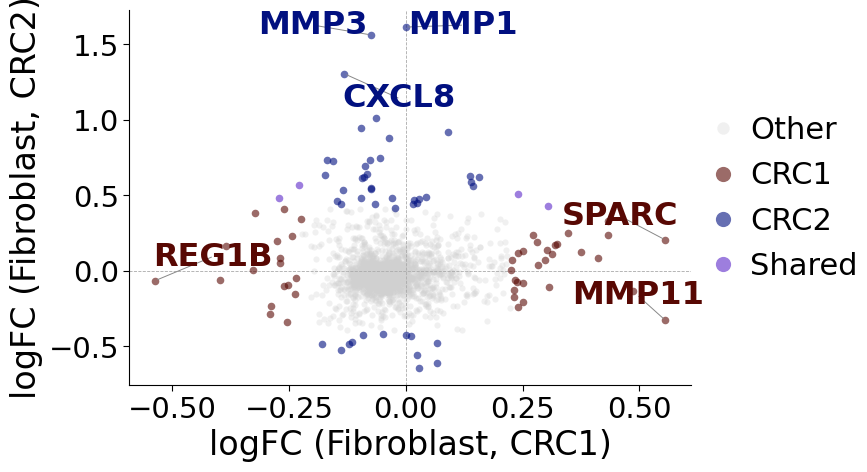

In [55]:
import matplotlib as mpl
from adjustText import adjust_text

mpl.rcParams.update({
    'font.family':       'sans-serif',
    # 'font.sans-serif':   ['Arial', 'Helvetica', 'DejaVu Sans'],
    'svg.fonttype':      'none',
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size':  4,
    'ytick.major.size':  4,
})

top_k = 50
gene_names = np.array(adata.var_names)
FS = 24

CATEGORIES = {
    'shared': dict(color='mediumpurple', label='Shared'),
    'cf1':    dict(color=palette['CRC1'], label=f'CRC1'),
    'cf2':    dict(color=palette['CRC2'], label=f'CRC2'),
}

top_cf1_genes = set(gene_names[np.argsort(-np.abs(lfc_cf1))[:top_k]])
top_cf2_genes = set(gene_names[np.argsort(-np.abs(lfc_cf2))[:top_k]])
in_top1 = np.isin(gene_names, list(top_cf1_genes))
in_top2 = np.isin(gene_names, list(top_cf2_genes))
in_both = in_top1 & in_top2

fig, ax = plt.subplots(figsize=(9, 5))

for mask, col, lbl, z, alpha, s in [
    (~in_top1 & ~in_top2, '#d0d0d0',                     'Other',                       0, 0.3, 20),
    (in_top1  & ~in_top2, CATEGORIES['cf1']['color'],    CATEGORIES['cf1']['label'],    1, 0.6, 30),
    (~in_top1 & in_top2,  CATEGORIES['cf2']['color'],    CATEGORIES['cf2']['label'],    1, 0.6, 30),
    (in_both,             CATEGORIES['shared']['color'],  CATEGORIES['shared']['label'], 2, 0.9, 30),
]:
    ax.scatter(lfc_cf1[mask], lfc_cf2[mask],
               c=col, s=s, alpha=alpha, label=lbl,
               zorder=z, linewidths=0, rasterized=True)

ax.axhline(0, color='#aaaaaa', lw=0.6, ls='--', zorder=0)
ax.axvline(0, color='#aaaaaa', lw=0.6, ls='--', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

n_label = 3
texts = []

def label_top(mask, score, color):
    idx = np.where(mask)[0]
    top_idx = idx[np.argsort(-np.abs(score[idx]))[:n_label]]
    for i in top_idx:
        x, y = lfc_cf1[i], lfc_cf2[i]
        texts.append(ax.text(x, y, gene_names[i],
                             fontsize=FS - 1, color=color,
                             fontweight='bold', zorder=5))

# label_top(in_both,            np.abs(lfc_cf1) + np.abs(lfc_cf2), CATEGORIES['shared']['color'])
label_top(in_top1 & ~in_top2, lfc_cf1,                            CATEGORIES['cf1']['color'])
label_top(~in_top1 & in_top2, lfc_cf2,                            CATEGORIES['cf2']['color'])

adjust_text(
    texts,
    ax=ax,
    expand=(1.3, 1.6),
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.7, shrinkA=1, shrinkB=2),
    force_text=(0.6, 0.9),
    force_points=(0.4, 0.6),
)

ax.set_xlabel(f'logFC ({is_celltype1}, CRC1)', fontsize=FS)
ax.set_ylabel(f'logFC ({is_celltype2}, CRC2)', fontsize=FS)
ax.tick_params(labelsize=FS - 3)
ax.legend(
    markerscale=2,
    fontsize=FS - 2,
    loc='center left',
    bbox_to_anchor=(1.03, 0.5),
    borderaxespad=0,
    frameon=False,
    handletextpad=0.4,
    labelspacing=0.5,
)

plt.tight_layout()
fig.savefig(f'{fig_save_path}/{slide_id}_cf_lfc_scatter.svg', format='svg', bbox_inches='tight', dpi=300)
plt.show()

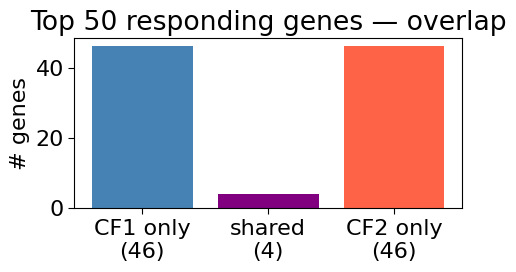

In [56]:

shared = top_cf1_genes & top_cf2_genes
fig, ax = plt.subplots(figsize=(5, 3))
counts = [len(top_cf1_genes - top_cf2_genes), len(shared), len(top_cf2_genes - top_cf1_genes)]
labels = [f'CF1 only\n({counts[0]})', f'shared\n({counts[1]})', f'CF2 only\n({counts[2]})']
ax.bar(labels, counts, color=['steelblue', 'purple', 'tomato'])
ax.set_ylabel('# genes')
ax.set_title(f'Top {top_k} responding genes — overlap')
plt.tight_layout()
plt.show()


## Systematic pathway CF correlation heatmap (all cell types × CRC1/CRC2)

In [57]:
# ── Precompute control/target mean expression for every (ct, domain) pair ─────
cell_types_sys = list(results.keys())   # Endothelial, Epithelial, Fibroblast, Myeloid, T_cell
domains_sys    = ['CRC1', 'CRC2']

ctrl_means   = {}   # ct -> mean log-normalised control expression (1-d, n_genes)
target_means = {}   # (ct, dom) -> mean log-normalised target expression

for ct in cell_types_sys:
    adata_ct = results[ct].copy()
    adata_ct.X = adata_ct.layers['counts'].copy()
    sc.pp.normalize_total(adata_ct, target_sum=1e4)
    sc.pp.log1p(adata_ct)

    X = np.asarray(adata_ct.X.todense()) if hasattr(adata_ct.X, 'todense') else np.asarray(adata_ct.X)

    mask_ctrl = ~adata_ct.obs['microenvironment'].astype(str).str.contains('CRC')
    ctrl_means[ct] = X[mask_ctrl].mean(axis=0)

    for dom in domains_sys:
        mask_tgt = adata_ct.obs['microenvironment'].astype(str) == dom
        n = int(mask_tgt.sum())
        print(f"  {ct} | {dom}: {n} target cells")
        target_means[(ct, dom)] = X[mask_tgt].mean(axis=0) if n > 0 else None

print("\nDone. Available target pairs:", [k for k, v in target_means.items() if v is not None])


  Endothelial | CRC1: 5132 target cells
  Endothelial | CRC2: 3025 target cells


  Epithelial | CRC1: 16135 target cells
  Epithelial | CRC2: 43155 target cells
  Fibroblast | CRC1: 29626 target cells
  Fibroblast | CRC2: 4661 target cells
  Myeloid | CRC1: 8285 target cells
  Myeloid | CRC2: 17002 target cells
  T_cell | CRC1: 5217 target cells
  T_cell | CRC2: 1572 target cells

Done. Available target pairs: [('Endothelial', 'CRC1'), ('Endothelial', 'CRC2'), ('Epithelial', 'CRC1'), ('Epithelial', 'CRC2'), ('Fibroblast', 'CRC1'), ('Fibroblast', 'CRC2'), ('Myeloid', 'CRC1'), ('Myeloid', 'CRC2'), ('T_cell', 'CRC1'), ('T_cell', 'CRC2')]


In [58]:
# ── Systematic CF computation: one make_neighbor_perturbation call per domain ─
from cellina._spatial_utils import make_neighbor_perturbation

domains_cfg = {
    'CRC1': {'ct_logfc': ct_logfc_df_crc1, 'pw_dfs': [pw_tgfb, pw_mapk]},
    'CRC2': {'ct_logfc': ct_logfc_df_crc2, 'pw_dfs': [pw_nfkb, pw_mapk]},
}

cf_means = {}   # (ct, dom) -> mean log-normalised CF expression (1-d, n_genes)

for dom, dom_cfg in domains_cfg.items():
    logfc_sub = build_perturbation_dict(dom_cfg['ct_logfc'], pw_dfs=dom_cfg['pw_dfs'])
    print(f"\n{dom}: perturbation vectors for {list(logfc_sub.keys())}")

    # Apply neighbourhood perturbation once for this domain
    adata.X = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    make_neighbor_perturbation(
        adata,
        perturbations=logfc_sub,
        groupby=labels_key,
        obsm_key_out='spatial_x_cf',
        base=np.e,
    )
    adata.X = adata.layers['counts'].copy()

    for ct in cell_types_sys:
        is_tumor = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
        idx_ctrl = np.where(~is_tumor & (adata.obs[labels_key] == ct))[0]
        if len(idx_ctrl) == 0:
            print(f"  {ct}: no control cells — skipping")
            continue
        print(f"  {ct}: {len(idx_ctrl)} control cells → running CF")

        cf_expr = model.get_perturbed_expression(
            adata,
            indices=idx_ctrl,
            batch_size=4096,
            spatial_obsm_key='spatial_x_cf',
            library_size=1e4,
        )
        cf_means[(ct, dom)] = np.log1p(cf_expr).mean(axis=0)

print("\nCF means computed for:", list(cf_means.keys()))



CRC1: perturbation vectors for ['B_cell', 'Endothelial', 'Epithelial', 'Fibroblast', 'Mast_cell', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']
  Endothelial: 3024 control cells → running CF
  Epithelial: 171115 control cells → running CF
  Fibroblast: 7006 control cells → running CF
  Myeloid: 9418 control cells → running CF
  T_cell: 7284 control cells → running CF

CRC2: perturbation vectors for ['B_cell', 'Endothelial', 'Epithelial', 'Fibroblast', 'Mast_cell', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']
  Endothelial: 3024 control cells → running CF
  Epithelial: 171115 control cells → running CF
  Fibroblast: 7006 control cells → running CF
  Myeloid: 9418 control cells → running CF
  T_cell: 7284 control cells → running CF

CF means computed for: [('Endothelial', 'CRC1'), ('Epithelial', 'CRC1'), ('Fibroblast', 'CRC1'), ('Myeloid', 'CRC1'), ('T_cell', 'CRC1'), ('Endothelial', 'CRC2'), ('Epithelial', 'CRC2'), ('Fibroblast', 'CRC2'), ('Myeloid', 'CRC2'), ('T_cell', 

In [59]:
from scipy.stats import spearmanr as _spear

DEG = 200

# ── Build pairs list (only pairs with valid data) ─────────────────────────────
pairs_sys = [
    (ct, dom)
    for ct in cell_types_sys
    for dom in domains_sys
    if target_means.get((ct, dom)) is not None and (ct, dom) in cf_means
]
print(f"Valid pairs ({len(pairs_sys)}): {pairs_sys}")

# ── Compute log-fold-change vectors (already in log1p space → subtract) ───────
gt_logfc_vecs = {
    (ct, dom): target_means[(ct, dom)] - ctrl_means[ct]
    for ct, dom in pairs_sys
}
cf_logfc_vecs = {
    (ct, dom): cf_means[(ct, dom)] - ctrl_means[ct]
    for ct, dom in pairs_sys
}

# ── Build Spearman correlation matrix (CF source × observed target) ────────────
# For each (row=CF source, col=GT target): select top DEG genes by |gt_logfc|,
# then compute Spearman r between cf_logfc[row] and gt_logfc[col] on those genes.
labels = [f"{ct}\n{dom}" for ct, dom in pairs_sys]
n = len(pairs_sys)
mat = np.full((n, n), np.nan)

for i, row_pair in enumerate(pairs_sys):
    if row_pair not in cf_logfc_vecs:
        continue
    cf_vec = cf_logfc_vecs[row_pair]
    for j, col_pair in enumerate(pairs_sys):
        if col_pair not in gt_logfc_vecs:
            continue
        gt_vec = gt_logfc_vecs[col_pair]
        top_g  = np.argsort(-np.abs(gt_vec))[:DEG]
        r, _   = _spear(cf_vec[top_g], gt_vec[top_g])
        mat[i, j] = r

spear_df = pd.DataFrame(mat, index=labels, columns=labels)
print(spear_df.round(3))

Valid pairs (10): [('Endothelial', 'CRC1'), ('Endothelial', 'CRC2'), ('Epithelial', 'CRC1'), ('Epithelial', 'CRC2'), ('Fibroblast', 'CRC1'), ('Fibroblast', 'CRC2'), ('Myeloid', 'CRC1'), ('Myeloid', 'CRC2'), ('T_cell', 'CRC1'), ('T_cell', 'CRC2')]
                   Endothelial\nCRC1  Endothelial\nCRC2  Epithelial\nCRC1  \
Endothelial\nCRC1              0.691              0.118             0.304   
Endothelial\nCRC2              0.580              0.417             0.230   
Epithelial\nCRC1               0.022              0.058             0.375   
Epithelial\nCRC2               0.005              0.062             0.158   
Fibroblast\nCRC1               0.313              0.244             0.299   
Fibroblast\nCRC2               0.298              0.452             0.223   
Myeloid\nCRC1                  0.254              0.187             0.349   
Myeloid\nCRC2                  0.193              0.355             0.228   
T_cell\nCRC1                   0.184              0.085     

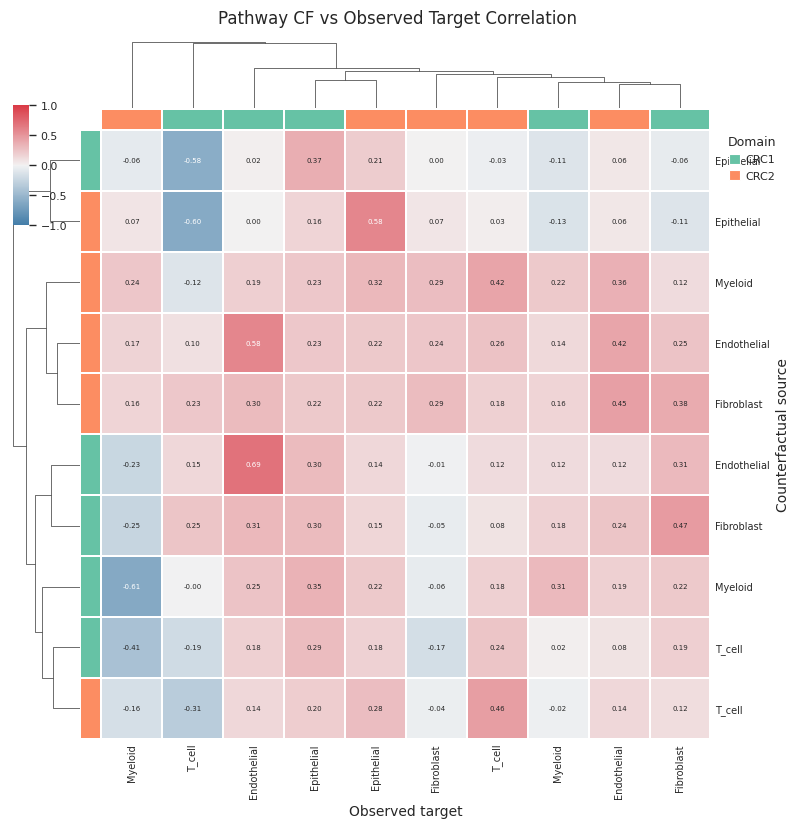

In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper", style="white", font_scale=0.9)

# ── Extract components ──
cell_types = [label.split('\n')[0] for label in spear_df.index]
domains = [label.split('\n')[1] for label in spear_df.index]

unique_domains = sorted(set(domains))
domain_palette = sns.color_palette("Set2", len(unique_domains))
domain_color_map = dict(zip(unique_domains, domain_palette))

row_colors = [domain_color_map[d] for d in domains]

# Replace index labels with ONLY cell types
spear_df_plot = spear_df.copy()
spear_df_plot.index = cell_types
spear_df_plot.columns = cell_types

# ── Handle NaNs ──
spear_df_filled = spear_df_plot.fillna(0)
nan_mask = spear_df_plot.isna()

# ── Plot ──
g = sns.clustermap(
    spear_df_filled,
    cmap=sns.diverging_palette(240, 10, as_cmap=True),
    center=0,
    vmin=-1, vmax=1,

    row_colors=row_colors,
    col_colors=row_colors,
    mask=nan_mask,

    figsize=(8, 8),  # smaller figure

    linewidths=0.2,
    linecolor='white',

    annot=True,
    fmt=".2f",
    annot_kws={"size": 5},

    dendrogram_ratio=0.1,
    cbar_pos=(0.02, 0.75, 0.02, 0.15),

    xticklabels=True,
    yticklabels=True
)

# ── Label formatting ──
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha='center', fontsize=7)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=7)

# ── Titles ──
g.fig.suptitle(
    "Pathway CF vs Observed Target Correlation",
    fontsize=12,
    y=1.02
)

g.ax_heatmap.set_xlabel("Observed target", fontsize=10)
g.ax_heatmap.set_ylabel("Counterfactual source", fontsize=10)

# ── Legend (domains only) ──
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=domain_color_map[d], label=d)
    for d in unique_domains
]

g.ax_heatmap.legend(
    handles=legend_elements,
    title="Domain",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
    fontsize=8,
    title_fontsize=9
)

# ── Clean look ──
g.ax_heatmap.tick_params(length=0)
for spine in g.ax_heatmap.spines.values():
    spine.set_visible(False)

# ── Save ──
plt.savefig(
    f'{fig_save_path}/{slide_id}_clustermap_final.svg',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [61]:
# ── Gene-permutation null for Spearman correlation ────────────────────────────
# For each iteration, permute the gene indices of gt_logfc_vecs before computing
# Spearman — null is centered near 0, showing correlations expected by chance.
from scipy.stats import spearmanr as _spear

N_PERM   = 200
rng_null = np.random.default_rng(42)
n_genes  = len(next(iter(gt_logfc_vecs.values())))

null_vals = []

for _ in range(N_PERM):
    perm = rng_null.permutation(n_genes)        # one gene-label shuffle per iter
    for row_pair in pairs_sys:
        if row_pair not in cf_logfc_vecs:
            continue
        cf_vec = cf_logfc_vecs[row_pair]
        for col_pair in pairs_sys:
            if col_pair not in gt_logfc_vecs:
                continue
            gt_perm = gt_logfc_vecs[col_pair][perm]         # permute gene labels
            top_g   = np.argsort(-np.abs(gt_perm))[:DEG]   # reselect top DEGs
            r, _    = _spear(cf_vec[top_g], gt_perm[top_g])
            null_vals.append(r)

null_vals = np.array(null_vals)
print(f"Null: n={len(null_vals):,}, mean={null_vals.mean():.3f}, std={null_vals.std():.3f}")


Null: n=20,000, mean=0.001, std=0.070


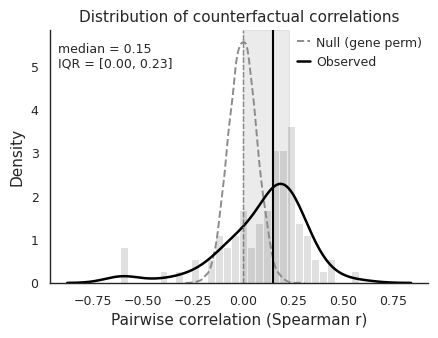

In [62]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", context="paper", font_scale=1.1)

# ── Extract off-diagonal correlations ──
vals = spear_df.values
off_diag = vals[~np.eye(vals.shape[0], dtype=bool)]
off_diag = off_diag[~np.isnan(off_diag)]

# ── Summary stats ──
median = np.median(off_diag)
q1, q3 = np.percentile(off_diag, [25, 75])

# ── Plot ──
fig, ax = plt.subplots(figsize=(4.5, 3.5))

# Histogram (light, for density support)
sns.histplot(
    off_diag,
    bins=30,
    stat="density",
    color="0.7",
    edgecolor=None,
    alpha=0.4,
    ax=ax
)

# Null KDE (gene-permutation baseline)
sns.kdeplot(
    null_vals,
    bw_adjust=1.0,
    color="0.55",
    linewidth=1.4,
    linestyle="--",
    label="Null (gene perm)",
    ax=ax,
)

# Observed KDE (main signal)
sns.kdeplot(
    off_diag,
    bw_adjust=1.0,
    color="black",
    linewidth=1.8,
    label="Observed",
    ax=ax,
)

# ── Reference lines ──
ax.axvline(0,              linestyle="--", linewidth=1,   color="black",  alpha=0.4)
ax.axvline(null_vals.mean(), linestyle=":",  linewidth=1,   color="0.55")
ax.axvline(median,         linestyle="-",  linewidth=1.5, color="black")

# IQR band
ax.axvspan(q1, q3, color="black", alpha=0.08)

# ── Labels ──
ax.set_xlabel("Pairwise correlation (Spearman r)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Distribution of counterfactual correlations", fontsize=11)

# ── Legend + clean style ──
ax.legend(fontsize=9, frameon=False)
sns.despine(ax=ax)
ax.tick_params(axis="both", labelsize=9)

# ── Annotation text ──
ax.text(
    0.02, 0.95,
    f"median = {median:.2f}\nIQR = [{q1:.2f}, {q3:.2f}]",
    transform=ax.transAxes,
    ha="left", va="top", fontsize=9,
)

plt.tight_layout()
plt.savefig(
    f"{fig_save_path}/{slide_id}_correlation_distribution.svg",
    dpi=300, bbox_inches="tight",
)
plt.show()
